# Synthetic Bumblebee Prompt Testing

Rapid iteration notebook for testing GPT-image-1.5 prompts + reference images.

**Workflow:**
1. Pick a species and configure prompt parameters (morphology, viewpoint, environment, scale)
2. Generate N images (default 10) via OpenAI edit API (synchronous, not batch)
3. Display in a grid for visual comparison
4. Log experiments with prompt version, parameters, and notes

In [137]:
import base64
import json
import sys
import time
from datetime import datetime
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display, HTML
from PIL import Image

sys.path.insert(0, str(Path.cwd().parent))
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
client = OpenAI()

PROJECT_ROOT = Path.cwd().parent
REFERENCES_DIR = PROJECT_ROOT / "references"
RESULTS_DIR = PROJECT_ROOT / "RESULTS"
PROMPT_TEMPLATE_FILE = PROJECT_ROOT / "configs" / "prompt_template.txt"

print(f"Project root: {PROJECT_ROOT}")
print(f"References: {list(REFERENCES_DIR.iterdir()) if REFERENCES_DIR.exists() else 'NOT FOUND'}")

Project root: /home/msun14/bumblebee_bplusplus
References: [PosixPath('/home/msun14/bumblebee_bplusplus/references/.DS_Store'), PosixPath('/home/msun14/bumblebee_bplusplus/references/Bombus_sandersoni'), PosixPath('/home/msun14/bumblebee_bplusplus/references/Bombus_ashtoni'), PosixPath('/home/msun14/bumblebee_bplusplus/references/Bombus_flavidus')]


## Species Morphology (Field Guide Descriptions)

All 16 MA species. Descriptions from Xerces Eastern Bumble Bee Guide, BumbleBeeWatch, and taxonomic literature. Edit any description below to test prompt variations.

In [138]:
# ── Species morphological descriptions (REFINED) ─────────────────────────────
# Verified against: Xerces "Bumble Bees of the Eastern United States" (Colla
#   et al. 2011), Williams et al. "Bumble Bees of North America" (Princeton,
#   2014), BumbleBeeWatch field guide, Montana Field Guide, Wisconsin BBB,
#   Vermont Atlas of Life, USFWS species profiles, Discover Life keys,
#   Florida EENY-050 key (Schuh et al. 2024), and Bee Watching species accounts.
#
# Corrections applied 2026-04-01 after systematic cross-referencing.
# Colors refer to pile (hair) unless otherwise stated.
# Tergite numbering: T1 = first visible abdominal tergite (propodeal tergite
#   fused to thorax), T2–T6 (females) or T2–T7 (males).
# Where queen and worker patterns differ materially, both are given.

SPECIES_MORPHOLOGY = {

    # ─────────────────────────────────────────────────────────────────────────
    # SUBGENUS PYROBOMBUS
    # ─────────────────────────────────────────────────────────────────────────

    "Bombus_impatiens": {
        "species_name": "Bombus impatiens",
        "common_name": "Common eastern bumble bee",
        "morphological_description": (
            "Medium-large bumble bee (queen 21–23 mm, worker 9–16 mm). Head with "
            "black face and vertex; males with conspicuous yellow facial hair forming "
            "a moustache-like patch below antennae. Thorax covered in bright lemon-yellow "
            "pile with a distinct, well-defined bare black spot in the centre of the "
            "thoracic dorsum between the wing bases — not a diffuse band. T1 entirely "
            "lemon-yellow. T2–T5 (females) or T2–T6 (males) entirely black. Rare red "
            "morph exists: T1 yellow, T2–T3 rust/red, T4–T5 black. Hair short and even; "
            "metasoma rather long and rectangular in outline. Midleg basitarsus with "
            "distal posterior corner rounded. Cheek approximately as long as broad. "
            "Wings lightly tinted brown. Corbiculae present on hind tibiae (shiny, "
            "concave, fringed with long hairs). Parasitised by B. citrinus."
        ),
    },

    "Bombus_bimaculatus": {
        "species_name": "Bombus bimaculatus",
        "common_name": "Two-spotted bumble bee",
        "morphological_description": (
            "Medium bumble bee (queen 20–22 mm, worker 10–16 mm). Head with black face "
            "and vertex; face relatively long. Thorax predominantly yellow with a dense, "
            "always-present patch of black hair between the wing bases. T1 yellow. T2 "
            "with a yellow patch centrally whose posterior margin forms a characteristic "
            "W-shape (notched or bilobed), bordered laterally and posteriorly by black "
            "hair — the yellow spot may be partly hidden beneath folded wings. T3–T5 "
            "(females) or T3–T6 (males) black. Hair long and somewhat uneven; metasoma "
            "rather short and globular in outline. Cheek slightly longer than broad. "
            "Wings lightly tinted brown. Corbiculae present. Can be confused with "
            "B. impatiens (which lacks any yellow on T2) and B. vagans."
        ),
    },

    "Bombus_griseocollis": {
        "species_name": "Bombus griseocollis",
        "common_name": "Brown-belted bumble bee",
        "morphological_description": (
            "Medium bumble bee (queen 19–22 mm, worker 9–15 mm). Head with black face "
            "and vertex; ocelli conspicuously large and bulging. Thorax predominantly "
            "yellow with a distinct round bare black spot on the scutum between wing "
            "bases — typically only a few black hairs at the edges of this spot, not a "
            "dense patch. T1 yellow. T2 with a brown or pale-orange anterior band "
            "(sometimes described as a crescent), flanked laterally and posteriorly by "
            "black hair. T3–T5 (females) black. Hair very short, dense, and even — "
            "a distinctive buzz-cut appearance. Metasoma rather rectangular and slightly "
            "flattened. Cheek distinctly shorter than broad. Wings lightly tinted. "
            "Corbiculae present. Can be confused with B. affinis workers (which have a "
            "more distinctly rusty T2 patch surrounded by yellow, and a V-shaped thoracic "
            "black mark)."
        ),
    },

    "Bombus_perplexus": {
        "species_name": "Bombus perplexus",
        "common_name": "Confusing bumble bee",
        "morphological_description": (
            "Medium bumble bee (queen 18–20 mm, worker 9–14 mm). Head with black face; "
            "top of head with mostly black hair, sometimes with a few pale hairs "
            "intermixed. Thorax predominantly brownish-yellow (pale pile often distinctly "
            "brownish rather than bright yellow), with only very few inconspicuous black "
            "hairs in the centre of the thoracic dorsum between wing bases — never forming "
            "a well-defined band or dense patch. Sides of thorax often with black hair. "
            "T1–T2 predominantly brownish-yellow. T3–T4 black. T5 variable — black or "
            "sometimes with white or pale hairs, especially laterally. Hair long and "
            "somewhat shaggy. Cheek slightly longer than broad. Wings lightly tinted. "
            "Corbiculae present. Highly variable; can be confused with B. vagans (which "
            "has brighter yellow pile and a more distinct thoracic black spot) and "
            "B. sandersoni."
        ),
    },

    "Bombus_vagans_Smith": {
        "species_name": "Bombus vagans",
        "common_name": "Half-black bumble bee",
        "morphological_description": (
            "Small to medium bumble bee (queen 17–19 mm, worker 8–13 mm). Head with "
            "black face; face relatively long. Thorax predominantly yellow with a black "
            "spot between the wing bases — spot small and well-defined in queens, but "
            "often larger and more diffuse in workers, sometimes expanding into a band "
            "between the wing bases. Sides of thorax yellow. T1 yellow. T2 yellow, "
            "sometimes with black along the posterior margin. T3–T5 (females) black. "
            "Hair long. Body size small but distinctly larger than B. sandersoni. "
            "Cheek slightly longer than broad. Wings lightly tinted. Corbiculae "
            "present. Readily forages in heavily shaded forest understorey. Can be "
            "confused with B. sandersoni (smaller, with shorter hair and shorter cheek) "
            "and B. perplexus (brownish pile, less distinct thoracic spot). "
            "Parasitised by B. citrinus."
        ),
    },

    "Bombus_sandersoni": {
        "species_name": "Bombus sandersoni",
        "common_name": "Sanderson's bumble bee",
        "morphological_description": (
            "DO NOT generate a generic yellow bumble bee. B. sandersoni is a SMALL, "
            "predominantly DARK bee — the rear half of the body is entirely black. "
            "Overall impression: a small, compact, half-black bumble bee with short "
            "even hair. Front half pale, rear half dark. "
            "HEAD: black face, round face shape, short cheek. "
            "THORAX: pale yellow on top with a black spot or band between the wing "
            "bases. Sides of thorax pale yellow. The yellow is pale/dingy, not bright "
            "lemon — duller than B. impatiens. "
            "ABDOMEN: T1 pale yellow. T2 pale yellow, often with scattered black "
            "hairs mixed in along the sides. T3–T5 ENTIRELY BLACK — this is the key "
            "visual feature: the rear half of the abdomen is solid black with NO "
            "yellow, orange, or white bands. "
            "HAIR: short and even — NOT long or shaggy. "
            "SIZE: distinctly small (worker 8–11 mm) — smallest of the half-black "
            "group. The bee should look small relative to flowers. "
            "LEGS: corbiculae present (flat, shiny hind tibiae with hair fringe). "
            "Wings lightly tinted."
        ),
    },

    "Bombus_ternarius_Say": {
        "species_name": "Bombus ternarius",
        "common_name": "Tri-colored bumble bee",
        "morphological_description": (
            "Medium bumble bee (queen 17–19 mm, worker 8–14 mm). Head with black face; "
            "face round, cheek approximately as long as broad. Hair of face and top of "
            "head black with patches of yellow. Thorax with yellow anterior band (usually "
            "without black hairs intermixed) and a black band between the wing bases "
            "extending posteriorly in a triangle towards the middle of the scutellum. "
            "Scutellum with yellow patches entirely divided by a black posteriorly-directed "
            "triangle. T1 yellow. T2–T3 distinctly orange to red (T2 with at most a "
            "few black hairs anterio-medially). T4 yellow. T5 black. Distinctive "
            "tri-colour pattern: yellow–orange–yellow–black. Hair short and even. "
            "Wings lightly tinted. Corbiculae present. Not easily confused with other "
            "species when fresh; faded females may resemble B. rufocinctus red morph "
            "or B. borealis."
        ),
    },

    "Bombus_rufocinctus": {
        "species_name": "Bombus rufocinctus",
        "common_name": "Red-belted bumble bee",
        "morphological_description": (
            "Small bumble bee (queen 16–18 mm, worker 8–13 mm). Highly variable in "
            "coloration — multiple colour morphs exist across and within populations. "
            "T2 almost always with at least a yellow crescent anteriorly (only rarely "
            "very reduced or absent). BLACK MORPH: mostly black with yellow anterior "
            "thorax; T1 yellow or black, T2 with narrow yellow anterior crescent, "
            "T3–T5 black. RED MORPH: orange/red bands on T2–T3, superficially similar "
            "to B. ternarius but lacking the clean tri-colour segmentation. YELLOW MORPH: "
            "T1–T2 yellow, T3–T5 black, resembling the half-black group. Thorax variable "
            "but usually with some yellow anteriorly and black between wing bases. Hair "
            "short and even. Cheek distinctly shorter than broad. Hind basitarsus with "
            "posterior margin evenly but not strongly arched. Body size small. Wings "
            "lightly tinted. Corbiculae present. Parasitised by B. flavidus."
        ),
    },

    # ─────────────────────────────────────────────────────────────────────────
    # SUBGENUS BOMBUS
    # ─────────────────────────────────────────────────────────────────────────

    "Bombus_terricola": {
        "species_name": "Bombus terricola",
        "common_name": "Yellow-banded bumble bee",
        "morphological_description": (
            "Medium bumble bee (queen 19–21 mm, worker 9–15 mm). Head with black face "
            "and mostly black vertex; hair of head black or with a minority of short "
            "pale hairs intermixed; face round, cheek slightly shorter than broad. "
            "Thorax with yellow pile anterior to the wing bases; posterior two-thirds "
            "of thoracic dorsum predominantly black — a variable black band or patch "
            "extends past the wing bases, sometimes reaching the scutellum, but always "
            "with yellow in front of the wing bases. Scutellum variable, sometimes with "
            "some yellow. ABDOMEN: T1 black (key diagnostic — always black, unlike "
            "B. pensylvanicus where T1 has medial yellow). T2–T3 yellow. T4 black. "
            "T5 with a diagnostic fringe of short yellow-brown hairs anteriorly — this "
            "T5 fringe is a key field mark separating B. terricola from B. pensylvanicus. "
            "T6 black. Abdominal pattern summary: B-Y-Y-B-b/y-B. Hair short and even. "
            "Clypeus strongly swollen in dorsal half. Hind basitarsus with posterior "
            "margin strongly and evenly arched. Wings slightly brownish. Corbiculae "
            "present. Uncommon, declining since mid-1990s. Parasitised by B. ashtoni "
            "(= B. bohemicus). Can be confused with B. pensylvanicus (which has T1 "
            "yellow medially, black scutellum, longer cheek, and lacks the T5 fringe)."
        ),
    },

    "Bombus_affinis": {
        "species_name": "Bombus affinis",
        "common_name": "Rusty-patched bumble bee",
        "morphological_description": (
            "Medium bumble bee (queen 20–22 mm, worker 9–15 mm). Federally listed "
            "as Endangered. Head with entirely black hair on face and top of head in "
            "all castes; face short. Cheek slightly shorter than broad; clypeus strongly "
            "swollen. QUEEN: Thorax mostly yellow with a small black spot or narrow "
            "V-shaped band between wing bases. T1–T2 entirely yellow (NO rusty patch "
            "in queens — this is critical). T3–T6 black. Queens emerge earlier than "
            "most other Bombus. WORKER: Thorax yellow with a more extensive black patch "
            "between wing bases extending towards the sides, forming a distinctive "
            "V-shape or thumbtack shape. T1 yellow. T2 with a diagnostic rusty-brown "
            "patch on the anterior half, surrounded by yellow hairs on the posterior "
            "half and sides — the eponymous rusty patch (variable in intensity from "
            "brown to orange). T3–T5 black. MALE: Similar to worker; T2 with rusty "
            "patch, but patch may be less distinct. Hair of medium length and even. "
            "Wings lightly tinted. Corbiculae present (flat, shiny hind tibiae with "
            "fringe). Rare after late 1990s. Parasitised by B. ashtoni (= B. bohemicus). "
            "Can be confused with B. griseocollis (which has a round black spot rather "
            "than V-shaped thoracic mark, brown T2 flanked by black not yellow, and "
            "very short buzz-cut hair)."
        ),
    },

    # ─────────────────────────────────────────────────────────────────────────
    # SUBGENUS THORACOBOMBUS
    # ─────────────────────────────────────────────────────────────────────────

    "Bombus_pensylvanicus": {
        "species_name": "Bombus pensylvanicus",
        "common_name": "American bumble bee",
        "morphological_description": (
            "Large bumble bee (queen 22–26 mm, worker 13–19 mm) — one of the largest "
            "eastern Bombus. Head with black face and vertex; top of head always black; "
            "face long, cheek slightly longer than broad; clypeus with large, coarse "
            "punctures except on midline. Thorax with yellow pile on pronotum and "
            "anterior portion of scutum; scutellum usually black or with only a few "
            "yellow hairs intermixed (key diagnostic: scutellum predominantly black, "
            "unlike B. fervidus where it is yellow). Black band between wing bases "
            "extending under the tegulae onto sides of thorax. Lower and lateral "
            "surfaces of thorax predominantly black. T1 with yellow hairs, especially "
            "medially (often yellow at centre, black laterally — key distinction from "
            "B. terricola where T1 is entirely black). T2–T3 yellow. T4–T5 black. "
            "T5 always black — no yellow-brown fringe (unlike B. terricola). Wings "
            "distinctly dark, more so than B. fervidus. Midleg basitarsus with distal "
            "posterior corner sharply and narrowly produced as a spine. Hind basitarsus "
            "with proximal posterior process long and pointed. Hair short and even. "
            "Corbiculae present with black fringes. Uncommon, severely declining — "
            "range contracted approximately 90% since early 2000s."
        ),
    },

    "Bombus_fervidus": {
        "species_name": "Bombus fervidus",
        "common_name": "Golden northern bumble bee",
        "morphological_description": (
            "Medium-large bumble bee (queen 19–22 mm, worker 10–16 mm). Head with black "
            "face and vertex; face long, cheek distinctly longer than broad; clypeus "
            "surface rough with many large punctures (diagnostic vs B. borealis where "
            "clypeus is very smooth and shiny). Thorax with bright lemon-yellow pile "
            "anteriorly and a distinct black band between the wing bases. Sides of "
            "thorax yellow, extending to or nearly to the bases of the legs (key "
            "diagnostic: lower sides yellow, unlike B. borealis and B. pensylvanicus "
            "where lower sides are predominantly black). Scutellum with yellow pile "
            "(key diagnostic vs B. pensylvanicus where scutellum is usually black). "
            "T1–T4 bright lemon-yellow (brighter and more vivid than the darker amber "
            "tones of B. borealis). T5 black. T6 black. Wings distinctly dark, "
            "dark grey to brownish-black. Midleg basitarsus with distal posterior "
            "corner sharply pointed. Hair of medium length and even; pile thick. "
            "Hair of head black or with only a minority of short pale hairs intermixed. "
            "Corbiculae present. Can be confused with B. borealis (which has yellow "
            "facial hair, darker amber body colour, black lower thorax sides, and smooth "
            "shiny clypeus) and B. pensylvanicus (which has black scutellum, black "
            "thorax sides, and darker wings)."
        ),
    },

    "Bombus_borealis": {
        "species_name": "Bombus borealis",
        "common_name": "Northern amber bumble bee",
        "morphological_description": (
            "Medium bumble bee (queen 19–21 mm, worker 10–15 mm). Head with grey-yellow "
            "to pale yellow hair on face and vertex — face distinctly paler than the "
            "rest of the body (key diagnostic: yellow face, unlike B. fervidus which "
            "has black face). Cheek distinctly longer than broad; clypeus very smooth "
            "and shiny with only a few very small punctures near centre (diagnostic "
            "vs B. fervidus where clypeus is rough and coarsely punctured). Thorax "
            "with a black band between the wing bases. Lower and lateral surfaces of "
            "thorax predominantly black (key diagnostic: black lower sides, unlike "
            "B. fervidus where sides are yellow to leg bases). Upper portions of "
            "thorax yellow. T1–T4 yellow, but in a darker amber or tawny tone — "
            "distinctly less vivid than the bright lemon-yellow of B. fervidus. "
            "T5 usually mostly black, sometimes with intermixed black and yellow hairs "
            "or a fringe of yellow. T6 black. Sides of T2–T4 sometimes with "
            "intermixed black hairs. Wings lightly tinted, less dark than B. fervidus. "
            "Midleg basitarsus with distal posterior corner sharply pointed. Hair of "
            "medium length and even. Corbiculae present. Can be confused with "
            "B. fervidus (brighter yellow, black face, rough clypeus, yellow thorax "
            "sides) and B. pensylvanicus (black scutellum, darker wings, black face)."
        ),
    },

    # ─────────────────────────────────────────────────────────────────────────
    # SUBGENUS PSITHYRUS (cuckoo bumble bees — obligate social parasites)
    # All Psithyrus lack corbiculae: hind tibiae convex and densely hairy
    # (no flat, shiny pollen basket). No worker caste produced.
    # ─────────────────────────────────────────────────────────────────────────

    "Bombus_citrinus": {
        "species_name": "Bombus citrinus",
        "common_name": "Lemon cuckoo bumble bee",
        "morphological_description": (
            "Social parasite (subgenus Psithyrus); female 15–19 mm. No worker caste. "
            "Head with black face; malar space shorter than broad (short, round face). "
            "Hair of face black, usually with only a minority of yellow hairs intermixed. "
            "Thorax predominantly yellow on dorsum and including lower sides — usually "
            "without black hair on the thoracic dorsum, or if present, not forming a "
            "band between the wing bases. Thorax appears entirely or almost entirely "
            "lemon-yellow from above. ABDOMEN: T1 black or with tufts of yellow pile "
            "laterally. T2 predominantly black, sometimes with a posterior fringe of "
            "yellow hairs. T3 with a diagnostic yellow band — the single most "
            "recognisable field mark for this species in females. T4–T5 predominantly "
            "black. T6 matte with dense punctures. Abdomen shiny (thickened, sclerotised "
            "tergites characteristic of Psithyrus). MALES: T1–T3 typically yellow, "
            "combined with short black face — distinctive. Hind tibia with outer surface "
            "convex and densely hairy — LACKS corbiculae (no pollen baskets). Wings "
            "light brown. Hair on metasoma short and even. Mandibles enlarged. Cuticle "
            "robust and heavily sclerotised. Hosts: B. impatiens, B. vagans, "
            "B. bimaculatus."
        ),
    },

    "Bombus_ashtoni": {
        "species_name": "Bombus bohemicus (inc. ashtoni)",
        "common_name": "Ashton's cuckoo bumble bee",
        "morphological_description": (
            "WARNING: This is NOT a typical yellow-and-black bumble bee. Do NOT "
            "generate a bee with bright yellow thorax and black abdomen like "
            "B. impatiens. B. ashtoni is a PREDOMINANTLY DARK bee — mostly black "
            "with only limited pale markings. "
            "Overall impression: a large, robust, dark bumble bee. The body is "
            "mostly black/dark brown with a pale yellow collar at the front of the "
            "thorax and a distinctive pale band on T4 near the tail end. "
            "HEAD: entirely black face and top of head. "
            "THORAX: pale yellow COLLAR on the front edge only. The rest of the "
            "thorax is predominantly BLACK — sides black, between wing bases black. "
            "Some pale yellow at the very rear (scutellum). The thorax should NOT "
            "appear mostly yellow — it should appear mostly dark with a yellow "
            "collar strip across the front. "
            "ABDOMEN: T1 DARK — mostly black/fuscous with sparse yellow hairs at "
            "sides. T2 DARK — mostly black. T3 dark with some pale hairs laterally. "
            "T4 has a WHITISH or PALE CREAM BAND — this is the single most "
            "important field mark. T5–T6 dark/black. "
            "LEGS: NO CORBICULAE — hind tibiae are convex and covered in dense "
            "hair (NOT flat and shiny like typical bumble bees). This is a cuckoo "
            "bee (social parasite). "
            "BUILD: robust, heavily sclerotised exoskeleton. Wings slightly darkened. "
            "Hair medium length. Female 15–20 mm."
        ),
    },

    "Bombus_flavidus": {
        "species_name": "Bombus flavidus",
        "common_name": "Flavid cuckoo bumble bee",
        "morphological_description": (
            "Do NOT generate a generic bumble bee. B. flavidus has a distinctive "
            "pattern: yellow front, BLACK middle, pale band near the tail. "
            "Overall impression: a medium-dark cuckoo bumble bee with an alternating "
            "yellow–black–yellow pattern on the abdomen, and yellow hair on the back "
            "of the head (unique among eastern Psithyrus). "
            "HEAD: face BLACK. Back of head (vertex and occiput) with YELLOW hair — "
            "this yellow-haired back-of-head is a KEY DIAGNOSTIC separating B. flavidus "
            "from B. ashtoni (which has a black head). "
            "THORAX: mostly yellow on top with a black spot or narrow band between "
            "wing bases. More yellow than B. ashtoni but not as bright as B. impatiens. "
            "ABDOMEN: T1 pale yellow. T2 BLACK — this creates a visible dark band "
            "between the yellow thorax/T1 and the variable T3. T3 variable (black "
            "or with some yellow). T4 broadly PALE YELLOW or CREAM — a continuous "
            "unbroken band with NO black interruption in the centre (key diagnostic). "
            "T5–T6 black. T6 shiny. "
            "The abdomen pattern from front to back is: yellow – BLACK – variable – "
            "CREAM BAND – black. This alternating pattern is distinctive. "
            "LEGS: NO CORBICULAE — hind tibiae convex and densely hairy (NOT flat "
            "and shiny). This is a cuckoo bee (social parasite). "
            "Hair medium-length and somewhat uneven. Wings light brown. "
            "Female 17–18 mm."
        ),
    },
}

print(f"Defined {len(SPECIES_MORPHOLOGY)} species")
for sp in sorted(SPECIES_MORPHOLOGY):
    print(f"  {sp}")

Defined 16 species
  Bombus_affinis
  Bombus_ashtoni
  Bombus_bimaculatus
  Bombus_borealis
  Bombus_citrinus
  Bombus_fervidus
  Bombus_flavidus
  Bombus_griseocollis
  Bombus_impatiens
  Bombus_pensylvanicus
  Bombus_perplexus
  Bombus_rufocinctus
  Bombus_sandersoni
  Bombus_ternarius_Say
  Bombus_terricola
  Bombus_vagans_Smith


## Prompt Template & Generation Config

All aspects are configurable: template text, viewpoints, environments, scale instructions, model parameters.

In [ ]:
import random

# ── Prompt template ────────────────────────────────────────────────────────────
# Placeholders: {species_name}, {common_name}, {caste_description},
#               {morphological_description}, {view_angle}, {wings_style},
#               {environment_description}, {scale_instruction}

PROMPT_TEMPLATE = """You are an expert in insect morphology and photorealistic rendering in natural settings.

Task:
You are provided with reference photographs of a real {species_name} ({common_name}). Study the reference images carefully — they show the exact species you must reproduce. Generate a distinct, photorealistic image of the same insect from a {view_angle} perspective.
The reference images define the ground truth for this species' morphology, pile colour, banding pattern, and texture. Your output must match these visual features precisely. Do not invent or alter colour patterns — copy them from the references.

Subject identity:
{caste_description}

Morphological notes:
{species_name} ({common_name})
{morphological_description}
All anatomical proportions, hair density, and color boundaries must remain accurate.

Scale and proportion:
{scale_instruction}

Pose and viewpoint constraints:
•    {view_angle} perspective should be preserved.
•    Wings must be {wings_style}
•    Natural variation in pose is required across images (leg positions, body posture).
•    Camera variation is allowed (tilt and shift)

Lighting variation:
•    Lighting conditions must vary naturally across images (sun angle, softness, shadow direction).
•    Use realistic outdoor lighting only.

Background requirements:
•    {environment_description}
•    Depth of field may vary from shallow to deep depending on camera distance and focal length, consistently with camera-trap photography.
•    Flower density and spatial arrangement must vary across images.
•    Background elements must be irregular and non-repeating and must not dominate the frame.

Flower realism constraints:
•    Flowers must show natural biological imperfections.
•    Petals may be uneven, slightly asymmetrical, bent, partially damaged, or irregular in shape.
•    Some flowers may be partially occluded, wilted, or past peak bloom.
•    Avoid idealized, perfectly radial, or textbook flower geometry.

Quality constraints:
•    No artifacts, repetitions, cloned patterns, or unnatural geometry.
•    The scene must look like a real camera-trap photograph, not a studio setup or synthetic render.
•    Across the generated batch avoid repeating the same composition, flower arrangement, lighting direction, or insect framing
•    The background flowers, and lighting, must not introduce cues that could be uniquely associated with this species, it must be as generic as possible"""

# ── View angles ───────────────────────────────────────────────────────────────
VARIATIONS = [
    {"view_angle": "lateral", "wings_style": "folded over the abdomen at rest"},
    {"view_angle": "dorsal", "wings_style": "folded over the abdomen at rest"},
    {"view_angle": "three-quarter anterior", "wings_style": "slightly spread"},
    {"view_angle": "three-quarter posterior", "wings_style": "folded over the abdomen at rest"},
    {"view_angle": "frontal", "wings_style": "slightly spread"},
]

# ── CASTE_OPTIONS — generation targets only ───────────────────────────────────
# B. sandersoni: eusocial (worker / queen / male)
# B. ashtoni:    Psithyrus cuckoo (female / male — NO workers)
# B. flavidus:   Psithyrus cuckoo (female / male — NO workers)
# ──────────────────────────────────────────────────────────────────────────────

CASTE_OPTIONS = {

    "Bombus_sandersoni": {
        "worker": (
            "This is a WORKER (female, 8–11 mm). Very small bee. "
            "Colour summary: pale yellow front half, solid black rear half. "
            "Thorax pale yellow with black between wings. T1–T2 pale yellow "
            "(T2 may have scattered black hairs at sides). T3–T5 entirely "
            "BLACK — no bands, no patches, just solid black. "
            "Corbiculae present (flat shiny hind tibiae). Short even hair."
        ),
        "queen": (
            "This is a QUEEN (female, 15–17 mm). Same colour pattern as "
            "worker — pale yellow front, black rear — but noticeably larger. "
            "Thorax pale yellow with well-defined black spot between wings. "
            "T1–T2 pale yellow, T3–T5 solid black. Corbiculae present."
        ),
        "male": (
            "This is a MALE (9–12 mm). Yellow facial hair (unlike females). "
            "T1–T2 yellow, possibly more extensive yellow than females. "
            "T3+ mostly black. Antennae longer (13 segments). "
            "NO corbiculae — hind tibiae convex and hairy."
        ),
    },

    "Bombus_ashtoni": {
        "female": (
            "This is a FEMALE (15–20 mm). "
            "CRITICAL: this bee is MOSTLY BLACK. Do NOT make it look like a "
            "typical yellow-and-black bumble bee. "
            "Colour summary from front to back: pale yellow collar → BLACK "
            "thorax → BLACK T1 → BLACK T2 → BLACK T3 → PALE WHITISH BAND "
            "on T4 → BLACK T5–T6. "
            "The ONLY yellow is a narrow collar at the front of the thorax "
            "and some pale at the scutellum. The abdomen is almost entirely "
            "dark except for the pale T4 band. "
            "NO CORBICULAE — hind legs are convex and densely hairy, NOT "
            "flat and shiny. Robust heavily-built body. Wings darkened."
        ),
        "male": (
            "This is a MALE (13–16 mm). Still predominantly dark but with "
            "slightly more pale hairs on vertex and thorax than female. "
            "T4 pale band may be less distinct. Antennae longer (13 segments). "
            "NO CORBICULAE — hind tibiae convex and densely hairy. "
            "Less robust than female."
        ),
    },

    "Bombus_flavidus": {
        "female": (
            "This is a FEMALE (17–18 mm). "
            "Colour summary from front to back: yellow back-of-head → "
            "yellow thorax (black between wings) → pale T1 → BLACK T2 → "
            "variable T3 → CREAM/YELLOW BAND on T4 → black T5–T6. "
            "Key features: (1) yellow hair on BACK OF HEAD (unique), "
            "(2) T2 is BLACK creating a dark band in the middle of the "
            "abdomen, (3) T4 has an UNBROKEN cream/yellow band with no "
            "black interruption. "
            "NOT as dark as B. ashtoni — more yellow overall. "
            "NO CORBICULAE — hind legs convex and densely hairy. "
            "T6 shiny. Wings light brown."
        ),
        "male": (
            "This is a MALE (11–15 mm). HIGHLY VARIABLE. May be mostly "
            "yellow — T1–T3 sometimes nearly all yellow, T4 yellow. "
            "T6–T7 often orange with paler tips. "
            "Antennae longer (13 segments). "
            "NO CORBICULAE — hind tibiae convex and densely hairy."
        ),
    },
}

# Default: species not listed above have minimal caste differences — use worker
DEFAULT_CASTE = "worker"

def get_caste_description(species: str, caste: str | None = None) -> tuple[str, str]:
    """Return (caste_name, caste_description) for a species.

    If caste is None, randomly selects from available castes weighted
    towards workers (most common in field photos).
    """
    if species not in CASTE_OPTIONS:
        c = caste or DEFAULT_CASTE
        return c, f"This is a {c}."

    options = CASTE_OPTIONS[species]
    if caste is not None:
        if caste in options:
            return caste, options[caste]
        else:
            # Fallback to first available
            c = list(options.keys())[0]
            return c, options[c]

    # Random selection weighted towards workers/females (most common in field)
    castes = list(options.keys())
    if "worker" in castes:
        weights = [3 if c == "worker" else 1 for c in castes]
    elif "female" in castes:
        weights = [3 if c == "female" else 1 for c in castes]
    else:
        weights = [1] * len(castes)
    c = random.choices(castes, weights=weights, k=1)[0]
    return c, options[c]


# ── Environment descriptions ─────────────────────────────────────────────────
# Expanded pool (15 environments) to reduce repetition across large batches.
# Environments are deliberately species-agnostic to avoid classifier shortcuts.
# generate_batch samples randomly instead of cycling deterministically.
ENVIRONMENTS = [
    # Meadow / open field
    "Natural outdoor meadow with low-growing wildflowers (clover, aster) in soft daylight",
    "Dry grassland with scattered knapweed and bird's-foot trefoil, hazy midday sun",
    "Open field with mixed grasses and dandelions, overcast diffuse lighting",
    "Unmowed roadside verge with Queen Anne's lace and chicory, flat even light",
    # Garden / cultivated
    "Sunny garden patch with sedum and goldenrod, warm afternoon light",
    "Backyard flower bed with zinnias and coneflowers, late morning sun with sharp shadows",
    "Community garden row with sunflowers and lavender, golden hour side-lighting",
    # Woodland edge
    "Woodland edge clearing with wild bergamot and milkweed, dappled sunlight",
    "Forest trail margin with jewelweed and asters, soft diffused light through canopy",
    "Shaded woodland floor with partridge berry and moss, cool ambient light",
    # Rocky / upland
    "Rocky hillside with low shrubs and wild thyme blossoms, morning light",
    "Sandy path edge with heath aster and sweet fern, bright overhead sun",
    # Wetland / riparian
    "Pond margin with joe-pye weed and boneset, humid overcast light",
    "Stream bank with cardinal flower and ironweed, late afternoon warm light",
    # Sparse / minimal
    "Bare soil patch near a gravel path with a single clover cluster, harsh midday shadow",
]

# ── Species-specific scale instructions ───────────────────────────────────────
# Worker body lengths from Williams et al. 2014 / Colla et al. 2011.
# Cuckoo species (Psithyrus) have no workers — female size is used.
SPECIES_BODY_SIZE = {
    "Bombus_impatiens":     {"size_mm": "9–16",  "label": "medium-large"},
    "Bombus_bimaculatus":   {"size_mm": "10–16", "label": "medium"},
    "Bombus_griseocollis":  {"size_mm": "9–15",  "label": "medium"},
    "Bombus_perplexus":     {"size_mm": "9–14",  "label": "medium"},
    "Bombus_vagans_Smith":  {"size_mm": "8–13",  "label": "small-medium"},
    "Bombus_sandersoni":    {"size_mm": "8–11",  "label": "small"},
    "Bombus_ternarius_Say": {"size_mm": "8–14",  "label": "medium"},
    "Bombus_rufocinctus":   {"size_mm": "8–13",  "label": "small"},
    "Bombus_terricola":     {"size_mm": "9–15",  "label": "medium"},
    "Bombus_affinis":       {"size_mm": "9–15",  "label": "medium"},
    "Bombus_pensylvanicus": {"size_mm": "13–19", "label": "large"},
    "Bombus_fervidus":      {"size_mm": "10–16", "label": "medium-large"},
    "Bombus_borealis":      {"size_mm": "10–15", "label": "medium"},
    "Bombus_citrinus":      {"size_mm": "15–19", "label": "medium"},
    "Bombus_ashtoni":       {"size_mm": "15–20", "label": "medium"},
    "Bombus_flavidus":      {"size_mm": "17–18", "label": "medium"},
}

def build_scale_instruction(species: str) -> str:
    """Build a species-specific scale instruction using proportional anchors."""
    info = SPECIES_BODY_SIZE.get(species)
    if info is None:
        body, label = "10–16", "medium"
    else:
        body = info["size_mm"]
        label = info["label"]
    return (
        f"CRITICAL SIZE CONSTRAINT — generated bees tend to be TOO LARGE relative to "
        f"flowers. You must correct for this. "
        f"This is a {label} bumblebee, body length {body} mm. "
        f"The bee should appear small in the frame, with ample surrounding environment "
        f"visible — similar to how a real macro field photograph frames the subject. "
        f"Proportional anchors: a white clover head is ~20 mm (same size as the bee or "
        f"LARGER), a red clover head is ~25 mm, an aster head is 30–50 mm (much wider "
        f"than the bee), a dandelion head is ~30 mm. "
        f"The bee must NEVER be larger than the flower it sits on. On clover, the bee "
        f"and flower should be roughly the same size. On aster or dandelion, the bee "
        f"should be noticeably smaller than the flower head. "
        f"If in doubt, make the bee SMALLER — an undersized bee is acceptable, "
        f"an oversized bee is not."
    )


# ── Model parameters ─────────────────────────────────────────────────────────
MODEL_CONFIG = {
    "model": "gpt-image-1.5",
    "size": "1024x1024",
    "quality": "medium",
    "output_format": "png",
}

print("Template loaded.")
print(f"  Placeholders: species_name, common_name, caste_description, morphological_description,")
print(f"                view_angle, wings_style, environment_description, scale_instruction")
print(f"  View angles: {[v['view_angle'] for v in VARIATIONS]}")
print(f"  Environments: {len(ENVIRONMENTS)} (randomly sampled per image)")
print(f"  Castes defined for: {list(CASTE_OPTIONS.keys())}")
print(f"  Scale: species-specific with frame-% guidance")

Template loaded.
  Placeholders: species_name, common_name, caste_description, morphological_description,
                view_angle, wings_style, environment_description, scale_instruction
  View angles: ['lateral', 'dorsal', 'three-quarter anterior', 'three-quarter posterior', 'frontal']
  Environments: 15 (randomly sampled per image)
  Castes defined for: ['Bombus_sandersoni', 'Bombus_ashtoni', 'Bombus_flavidus']
  Scale: species-specific with frame-% guidance


## Core Functions: Generate & Display

In [140]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}


def _convert_to_png_bytes(path: Path) -> BytesIO:
    """Convert any supported image to PNG bytes in memory.

    The edit endpoint is most reliable with PNG inputs.
    Avoids issues with JPEG EXIF rotation, WEBP alpha, etc.
    """
    img = Image.open(path)
    # Strip EXIF orientation if present
    if hasattr(img, "_getexif") and img._getexif():
        from PIL import ImageOps
        img = ImageOps.exif_transpose(img)
    # Convert to RGB if necessary (e.g. RGBA PNGs with transparency)
    if img.mode == "RGBA":
        bg = Image.new("RGB", img.size, (255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        img = bg
    elif img.mode != "RGB":
        img = img.convert("RGB")
    buf = BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    buf.name = path.stem + ".png"  # SDK uses .name for multipart filename
    return buf


def build_prompt(
    species: str,
    view_angle: str | None = None,
    environment: str | None = None,
    caste: str | None = None,
    template: str | None = None,
    morphology_override: str | None = None,
) -> str:
    """Build a filled prompt from template + species + variation parameters.

    If view_angle or environment is None, cycles through VARIATIONS/ENVIRONMENTS.
    """
    if template is None:
        template = PROMPT_TEMPLATE

    info = SPECIES_MORPHOLOGY[species]
    morph = morphology_override if morphology_override else info["morphological_description"]

    if view_angle is None:
        view_angle = "lateral"
    # Find matching wings_style
    wings = "folded over the abdomen at rest"
    for v in VARIATIONS:
        if v["view_angle"] == view_angle:
            wings = v["wings_style"]
            break

    if environment is None:
        environment = random.choice(ENVIRONMENTS)

    scale = build_scale_instruction(species)
    caste_name, caste_desc = get_caste_description(species, caste)

    return template.format(
        species_name=info["species_name"],
        common_name=info.get("common_name", ""),
        caste_description=caste_desc,
        morphological_description=morph,
        view_angle=view_angle,
        wings_style=wings,
        environment_description=environment,
        scale_instruction=scale,
    )


def get_reference_images(species: str, ref_dir: Path = REFERENCES_DIR) -> list[Path]:
    """Get reference image paths for a species, with validation."""
    sp_dir = ref_dir / species
    if not sp_dir.exists():
        print(f"WARNING: No reference dir at {sp_dir}")
        return []
    imgs = sorted(
        p for p in sp_dir.iterdir()
        if p.suffix.lower() in IMAGE_EXTENSIONS and p.stat().st_size > 0
    )
    if not imgs:
        print(f"WARNING: No valid images in {sp_dir}")
    else:
        print(f"Reference images for {species}: {[p.name for p in imgs]}")
    return imgs


def generate_single(
    prompt: str,
    ref_paths: list[Path] | None = None,
    model_config: dict | None = None,
) -> Image.Image:
    """Generate a single image.

    When ref_paths is provided, uses images.edit with reference images
    converted to PNG BytesIO handles (bare Path objects are NOT reliably
    accepted by the SDK's multipart upload).
    """
    if model_config is None:
        model_config = MODEL_CONFIG

    if ref_paths:
        # ── EDIT endpoint (reference-guided generation) ──────────────────
        # Validate paths exist
        for p in ref_paths:
            if not p.exists():
                raise FileNotFoundError(f"Reference image not found: {p}")

        # Convert to PNG BytesIO and wrap as (filename, BytesIO) tuples
        # SDK extract_files requires tuples for array uploads, bare BytesIO fails
        image_buffers = [_convert_to_png_bytes(p) for p in ref_paths]
        image_tuples = [(buf.name, buf) for buf in image_buffers]
        image_arg = image_tuples if len(image_tuples) > 1 else image_tuples[0]

        try:
            result = client.images.edit(
                model=model_config["model"],
                image=image_arg,
                prompt=prompt,
                n=1,
                size=model_config["size"],
                quality=model_config["quality"],
                input_fidelity="high",  # preserve reference morphology closely
            )
        finally:
            for buf in image_buffers:
                buf.close()
    else:
        # ── GENERATE endpoint (text-only, no reference) ──────────────────
        result = client.images.generate(
            model=model_config["model"],
            prompt=prompt,
            n=1,
            size=model_config["size"],
            quality=model_config["quality"],
            output_format=model_config.get("output_format", "png"),
        )

    # ── Decode response ──────────────────────────────────────────────────
    # gpt-image-1.5 returns b64_json
    img_data = result.data[0]
    if img_data.b64_json:
        img_bytes = base64.b64decode(img_data.b64_json)
        return Image.open(BytesIO(img_bytes))
    elif hasattr(img_data, "url") and img_data.url:
        import urllib.request
        with urllib.request.urlopen(img_data.url) as resp:
            return Image.open(BytesIO(resp.read()))
    else:
        raise ValueError(f"No image data in response. Keys: {vars(img_data).keys()}")


def generate_batch(
    species: str,
    n: int = 10,
    view_angles: list[str] | None = None,
    environments: list[str] | None = None,
    template: str | None = None,
    morphology_override: str | None = None,
    ref_paths: list[Path] | None = None,
    model_config: dict | None = None,
) -> list[dict]:
    """Generate n images with cycling viewpoints/environments.

    Returns list of {image: PIL.Image, prompt: str, view_angle: str, environment: str, index: int}
    """
    if view_angles is None:
        view_angles = [v["view_angle"] for v in VARIATIONS]
    if environments is None:
        environments = ENVIRONMENTS

    results = []
    for i in range(n):
        va = view_angles[i % len(view_angles)]
        env = random.choice(environments)

        caste_name, _ = get_caste_description(species)

        prompt = build_prompt(
            species, view_angle=va, environment=env,
            caste=caste_name,
            template=template,
            morphology_override=morphology_override,
        )

        print(f"  [{i+1}/{n}] {va} ({caste_name})...", end=" ", flush=True)
        t0 = time.time()
        try:
            img = generate_single(prompt, ref_paths=ref_paths, model_config=model_config)
            dt = time.time() - t0
            print(f"OK ({dt:.1f}s)")
            results.append({
                "image": img, "prompt": prompt, "view_angle": va,
                "environment": env, "caste": caste_name, "index": i,
            })
        except Exception as e:
            dt = time.time() - t0
            print(f"FAIL ({dt:.1f}s): {e}")
            results.append({
                "image": None, "prompt": prompt, "view_angle": va,
                "environment": env, "caste": caste_name, "index": i, "error": str(e),
            })

    ok = sum(1 for r in results if r["image"] is not None)
    print(f"\nGenerated {ok}/{n} images")
    return results


def display_grid(results: list[dict], cols: int = 5, figsize_per_img: float = 3.0,
                 save_path: Path | None = None):
    """Display generated images in a grid with labels. Optionally save to disk."""
    images = [r for r in results if r["image"] is not None]
    if not images:
        print("No images to display")
        return

    n = len(images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_img, rows * figsize_per_img))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]

    for idx, r in enumerate(images):
        row, col = divmod(idx, cols)
        ax = axes[row][col]
        ax.imshow(r["image"])
        caste = r.get("caste", "")
        label = f"#{r['index']} {r['view_angle']}"
        if caste:
            label += f" ({caste})"
        ax.set_title(label, fontsize=8)
        ax.axis("off")

    # Hide empty cells
    for idx in range(n, rows * cols):
        row, col = divmod(idx, cols)
        axes[row][col].axis("off")

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Grid saved to {save_path}")

    plt.show()


def save_experiment(
    results: list[dict],
    species: str,
    experiment_name: str,
    output_dir: Path | None = None,
    notes: str = "",
):
    """Save generated images and metadata to disk."""
    if output_dir is None:
        output_dir = PROJECT_ROOT / "RESULTS" / "prompt_testing" / experiment_name
    output_dir.mkdir(parents=True, exist_ok=True)

    manifest = {
        "experiment": experiment_name,
        "species": species,
        "timestamp": datetime.now().isoformat(),
        "model_config": MODEL_CONFIG,
        "notes": notes,
        "n_generated": sum(1 for r in results if r["image"] is not None),
        "n_failed": sum(1 for r in results if r["image"] is None),
        "images": [],
    }

    for r in results:
        if r["image"] is not None:
            caste = r.get("caste", "worker")
            fname = f"{species}_{r['index']:04d}_{caste}_{r['view_angle'].replace(' ', '_')}.png"
            r["image"].save(output_dir / fname, format="PNG")
            manifest["images"].append({
                "file": fname, "caste": caste,
                "view_angle": r["view_angle"],
                "environment": r["environment"],
            })
        if r["index"] == 0:
            manifest["prompt_sample"] = r["prompt"]

    (output_dir / "manifest.json").write_text(json.dumps(manifest, indent=2))
    print(f"Saved to {output_dir} ({manifest['n_generated']} images)")
    return output_dir


print("Functions defined: build_prompt, get_reference_images,")
print("  generate_single, generate_batch, display_grid, save_experiment")

Functions defined: build_prompt, get_reference_images,
  generate_single, generate_batch, display_grid, save_experiment


## Compare with Training Data

Show real GBIF images alongside generated images for visual comparison.

In [141]:
GBIF_DIR = PROJECT_ROOT / "GBIF_MA_BUMBLEBEES"
PREPARED_DIR = GBIF_DIR / "prepared"


def show_real_samples(species: str, n: int = 10, cols: int = 5, use_prepared: bool = True):
    """Display random real GBIF images for a species.

    Args:
        use_prepared: If True (default), show YOLO-cropped images from prepared/train.
                      If False, show raw uncropped GBIF images.
    """
    import random

    if use_prepared:
        sp_dir = PREPARED_DIR / "train" / species
        if not sp_dir.exists():
            print(f"No prepared training data for {species}")
            return
        all_imgs = sorted(p for p in sp_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)
        label = "Prepared (cropped, train)"
    else:
        sp_dir = GBIF_DIR / species
        if not sp_dir.exists():
            print(f"No GBIF data for {species}")
            return
        all_imgs = sorted(p for p in sp_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)
        label = "Raw GBIF"

    if not all_imgs:
        print(f"No images found for {species} ({'prepared' if use_prepared else 'raw'})")
        return

    print(f"{species}: {len(all_imgs)} {label.lower()} images")
    samples = random.sample(all_imgs, min(n, len(all_imgs)))

    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]

    fig.suptitle(f"{label}: {species}", fontsize=12, fontweight="bold")
    for idx, p in enumerate(samples):
        row, col = divmod(idx, cols)
        ax = axes[row][col]
        try:
            ax.imshow(Image.open(p))
        except Exception:
            ax.text(0.5, 0.5, "ERR", ha="center", va="center")
        ax.set_title(p.name[:30], fontsize=7)
        ax.axis("off")
    for idx in range(len(samples), rows * cols):
        row, col = divmod(idx, cols)
        axes[row][col].axis("off")
    fig.tight_layout()
    plt.show()


def side_by_side(species: str, generated_results: list[dict], n_real: int = 5, n_gen: int = 5):
    """Show real vs generated images side by side (uses prepared/cropped train images)."""
    import random

    sp_dir = PREPARED_DIR / "train" / species
    all_imgs = sorted(p for p in sp_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS) if sp_dir.exists() else []

    real_samples = random.sample(all_imgs, min(n_real, len(all_imgs))) if all_imgs else []
    gen_samples = [r for r in generated_results if r["image"] is not None][:n_gen]

    cols = max(len(real_samples), len(gen_samples))
    if cols == 0:
        print("No images to compare")
        return

    fig, axes = plt.subplots(2, cols, figsize=(cols * 3, 6))
    if cols == 1:
        axes = [[axes[0]], [axes[1]]]

    fig.suptitle(f"{species}: Real Cropped (top) vs Generated (bottom)", fontsize=12, fontweight="bold")

    for i in range(cols):
        if i < len(real_samples):
            axes[0][i].imshow(Image.open(real_samples[i]))
            axes[0][i].set_title("Real (cropped)", fontsize=8)
        axes[0][i].axis("off")
        if i < len(gen_samples):
            axes[1][i].imshow(gen_samples[i]["image"])
            axes[1][i].set_title(f"Gen: {gen_samples[i]['view_angle']}", fontsize=8)
        axes[1][i].axis("off")

    fig.tight_layout()
    plt.show()


print("Comparison functions defined: show_real_samples, side_by_side")

Comparison functions defined: show_real_samples, side_by_side


---
## Run Experiment

Configure and run below. Change any parameter to test variations.

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  EXPERIMENT CONFIG — edit this cell to test different settings   ║
# ╚═══════════════════════════════════════════════════════════════════╝

SPECIES = "Bombus_ashtoni"       # Change to any species in SPECIES_MORPHOLOGY
N_IMAGES = 10                     # Number of images to generate
EXPERIMENT_NAME = "ashtoni_v5"    # Name for saving results

# Override specific aspects (set to None to use defaults):
VIEW_ANGLES = None                # e.g., ["lateral", "dorsal"] or None for all 5
ENVIRONMENTS_OVERRIDE = None      # e.g., ["Custom env description"] or None for all 5
MORPHOLOGY_OVERRIDE = None        # e.g., "Custom morphology text" or None for default
TEMPLATE_OVERRIDE = None          # e.g., custom_template_string or None for default

# ── Preview the first prompt ──────────────────────────────────────────────────
sample_prompt = build_prompt(
    SPECIES,
    view_angle=(VIEW_ANGLES[0] if VIEW_ANGLES else None),
    environment=(ENVIRONMENTS_OVERRIDE[0] if ENVIRONMENTS_OVERRIDE else None),
    template=TEMPLATE_OVERRIDE,
    morphology_override=MORPHOLOGY_OVERRIDE,
)
print(f"Species: {SPECIES}")
print(f"N images: {N_IMAGES}")
print(f"Scale: {build_scale_instruction(SPECIES)[:80]}...")
print(f"\n{'='*70}")
print("SAMPLE PROMPT (first image):")
print(f"{'='*70}")
print(sample_prompt[:1500])
if len(sample_prompt) > 1500:
    print(f"\n... ({len(sample_prompt)} chars total)")

Species: Bombus_ashtoni
N images: 10
Scale: CRITICAL SIZE CONSTRAINT — generated bees tend to be TOO LARGE relative to flowe...

SAMPLE PROMPT (first image):
You are an expert in insect morphology and photorealistic rendering in natural settings.

Task:
You are provided with reference photographs of a real Bombus bohemicus (inc. ashtoni) (Ashton's cuckoo bumble bee). Study the reference images carefully — they show the exact species you must reproduce. Generate a distinct, photorealistic image of the same insect from a lateral perspective.
The reference images define the ground truth for this species' morphology, pile colour, banding pattern, and texture. Your output must match these visual features precisely. Do not invent or alter colour patterns — copy them from the references.

Subject identity:
This is a FEMALE (15–20 mm). CRITICAL: this bee is MOSTLY BLACK. Do NOT make it look like a typical yellow-and-black bumble bee. Colour summary from front to back: pale yellow collar → BLAC

In [143]:
# ── Show real GBIF images for comparison ──────────────────────────────────────
# show_real_samples(SPECIES, n=10)

In [144]:
# ── Get reference images ──────────────────────────────────────────────────────
ref_paths = get_reference_images(SPECIES)

if ref_paths:
    print(f"\nFound {len(ref_paths)} reference images (will use edit endpoint)")
else:
    ref_paths = None
    print("No reference images — will use generate endpoint (text-only)")

Reference images for Bombus_ashtoni: ['bombus_ashtoni.jpg', 'bombus_ashtoni_s.jpg']

Found 2 reference images (will use edit endpoint)


In [145]:
# ── Generate images ───────────────────────────────────────────────────────────
results = generate_batch(
    species=SPECIES,
    n=N_IMAGES,
    view_angles=VIEW_ANGLES,
    environments=ENVIRONMENTS_OVERRIDE,
    template=TEMPLATE_OVERRIDE,
    morphology_override=MORPHOLOGY_OVERRIDE,
    ref_paths=ref_paths,
)

# ── Auto-save results to disk ─────────────────────────────────────────────────
output_dir = save_experiment(results, SPECIES, EXPERIMENT_NAME, notes="auto-saved")

  [1/10] lateral (male)... OK (47.7s)
  [2/10] dorsal (female)... OK (51.2s)
  [3/10] three-quarter anterior (female)... OK (41.6s)
  [4/10] three-quarter posterior (male)... OK (47.4s)
  [5/10] frontal (female)... OK (44.8s)
  [6/10] lateral (female)... OK (48.9s)
  [7/10] dorsal (female)... OK (45.1s)
  [8/10] three-quarter anterior (female)... OK (47.2s)
  [9/10] three-quarter posterior (female)... OK (48.8s)
  [10/10] frontal (male)... OK (46.7s)

Generated 10/10 images
Saved to /home/msun14/bumblebee_bplusplus/RESULTS/prompt_testing/ashtoni_v_fidelity_high (10 images)


Grid saved to /home/msun14/bumblebee_bplusplus/RESULTS/prompt_testing/ashtoni_v_fidelity_high/grid.png


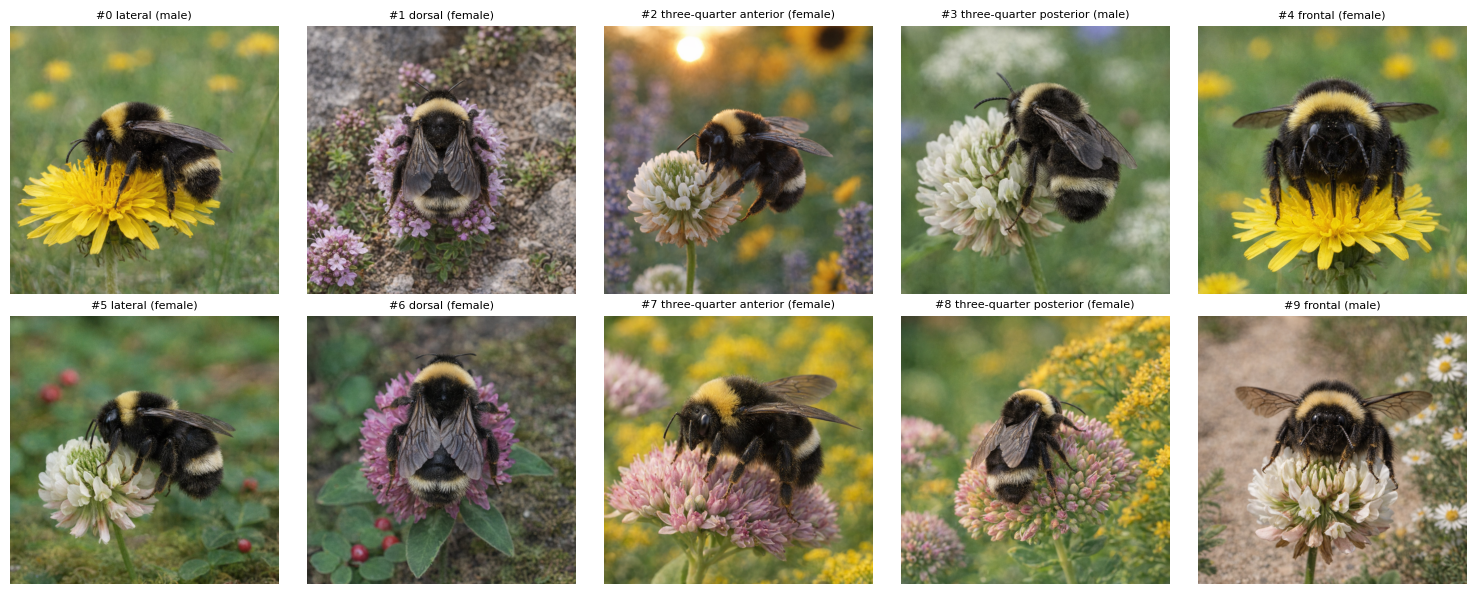

In [146]:
# ── Display generated images ──────────────────────────────────────────────────
grid_path = PROJECT_ROOT / "RESULTS" / "prompt_testing" / EXPERIMENT_NAME / "grid.png"
display_grid(results, cols=5, save_path=grid_path)

In [147]:
# ── Side-by-side: real vs generated ───────────────────────────────────────────
# side_by_side(SPECIES, results, n_real=5, n_gen=5)

In [149]:
# ── Save results (optional) ───────────────────────────────────────────────────
save_experiment(results, SPECIES, EXPERIMENT_NAME, notes="updated prompts")

Saved to /home/msun14/bumblebee_bplusplus/RESULTS/prompt_testing/ashtoni_v_fidelity_high (10 images)


PosixPath('/home/msun14/bumblebee_bplusplus/RESULTS/prompt_testing/ashtoni_v_fidelity_high')

---
## A/B Comparison

Generate with two different configs and compare side-by-side.

In [ ]:
def compare_experiments(
    species: str,
    config_a: dict,
    config_b: dict,
    n: int = 5,
    ref_paths: list | None = None,
):
    """Generate and compare two prompt configurations side-by-side.

    config_a/config_b are dicts with optional keys:
        template, morphology_override, view_angles, environments
    """
    label_a = config_a.pop("label", "Config A")
    label_b = config_b.pop("label", "Config B")

    print(f"=== Generating: {label_a} ===")
    results_a = generate_batch(species, n=n, ref_paths=ref_paths, **config_a)
    print(f"\n=== Generating: {label_b} ===")
    results_b = generate_batch(species, n=n, ref_paths=ref_paths, **config_b)

    imgs_a = [r for r in results_a if r["image"] is not None][:n]
    imgs_b = [r for r in results_b if r["image"] is not None][:n]
    cols = max(len(imgs_a), len(imgs_b))
    if cols == 0:
        print("No images to compare")
        return results_a, results_b

    fig, axes = plt.subplots(2, cols, figsize=(cols * 3, 6.5))
    if cols == 1:
        axes = [[axes[0]], [axes[1]]]
    fig.suptitle(f"{species}: {label_a} (top) vs {label_b} (bottom)", fontsize=12, fontweight="bold")

    for i in range(cols):
        if i < len(imgs_a):
            axes[0][i].imshow(imgs_a[i]["image"])
            axes[0][i].set_title(f"{label_a}: {imgs_a[i]['view_angle']}", fontsize=7)
        axes[0][i].axis("off")
        if i < len(imgs_b):
            axes[1][i].imshow(imgs_b[i]["image"])
            axes[1][i].set_title(f"{label_b}: {imgs_b[i]['view_angle']}", fontsize=7)
        axes[1][i].axis("off")

    fig.tight_layout()
    plt.show()
    return results_a, results_b


# ── Example A/B test: morphology override ─────────────────────────────────────
# Uncomment and run:

# results_a, results_b = compare_experiments(
#     SPECIES,
#     config_a={"label": "Original morph"},
#     config_b={"label": "Updated morph",
#               "morphology_override": "New description..."},
#     n=5,
#     ref_paths=ref_paths,
# )

print("compare_experiments() defined — uncomment above to run A/B test")

---
## Quick Reference: How to Test Different Aspects

```python
# Test different MORPHOLOGY description:
results = generate_batch("Bombus_flavidus", n=5, ref_paths=ref_paths,
    morphology_override="Custom morphological text here...")

# Test specific VIEW ANGLES only:
results = generate_batch("Bombus_ashtoni", n=5, ref_paths=ref_paths,
    view_angles=["lateral", "dorsal"])

# Test specific ENVIRONMENTS only:
results = generate_batch("Bombus_ashtoni", n=5, ref_paths=ref_paths,
    environments=["Custom environment: white studio background, no flowers"])

# Test completely different TEMPLATE:
custom_template = """Generate a photorealistic {view_angle} photo of {species_name}.
{morphological_description}
{scale_instruction}
Background: {environment_description}
Wings: {wings_style}"""
results = generate_batch("Bombus_ashtoni", n=5, ref_paths=ref_paths,
    template=custom_template)

# A/B compare two configs:
results_a, results_b = compare_experiments(
    "Bombus_ashtoni",
    config_a={"label": "Original morph"},
    config_b={"label": "Updated morph",
              "morphology_override": "New description..."},
    n=5, ref_paths=ref_paths,
)
```